# 📋 Admission Dashboard
### A complete view of admission inquiries, conversion rates, counsellor performance, and location trends.

In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

PALETTE = {
    'primary':   '#2563EB',
    'secondary': '#10B981',
    'accent':    '#F59E0B',
    'danger':    '#EF4444',
    'gray':      '#6B7280',
    'light':     '#F3F4F6',
    'courses': px.colors.qualitative.Pastel,
}

def clean_layout(fig, title='', height=400):
    fig.update_layout(
        title=dict(text=title, font=dict(size=15, color='#111827'), x=0),
        height=height,
        margin=dict(l=20, r=20, t=50, b=20),
        paper_bgcolor='white',
        plot_bgcolor='white',
        font=dict(family='Arial', size=12, color='#374151'),
        legend=dict(orientation='h', yanchor='bottom', y=1.02,
                    xanchor='right', x=1, bgcolor='rgba(0,0,0,0)',
                    font=dict(size=11)),
        xaxis=dict(showgrid=False, linecolor='#E2E8F0', tickfont=dict(size=11)),
        yaxis=dict(gridcolor='#F3F4F6', linecolor='#E2E8F0', tickfont=dict(size=11)),
    )
    return fig

print('✅ Libraries loaded.')

✅ Libraries loaded.


## 📂 1. Load & Prepare Data

In [2]:
admissions_raw = pd.read_csv('../data/admission.csv')

admissions_raw['admission_date']  = pd.to_datetime(admissions_raw['admission_date'], dayfirst=False, errors='coerce')
admissions_raw['admission_month'] = admissions_raw['admission_date'].dt.to_period('M').astype(str)
admissions_raw['is_admitted']     = admissions_raw['status'] == 'Admitted'

admissions = admissions_raw.copy()
print(f'Admissions: {len(admissions)} rows  |  Columns: {list(admissions.columns)}')

Admissions: 474 rows  |  Columns: ['admission_id', 'student_id', 'student_name', 'mobile_no', 'email', 'location', 'qualification', 'course', 'mode', 'admission_date', 'attended_by', 'status', 'admission_month', 'is_admitted']


## 🎛️ 2. Optional Filters

In [3]:
FILTER_COURSES   = []   # e.g. ['Data Science with Python', 'DevOps']
FILTER_MODES     = []   # e.g. ['Online']
FILTER_LOCATIONS = []   # e.g. ['Kochi', 'Calicut']

def apply(df, col, vals):
    return df[df[col].isin(vals)] if vals else df

admissions = apply(apply(apply(admissions_raw, 'course', FILTER_COURSES), 'mode', FILTER_MODES), 'location', FILTER_LOCATIONS)
print(f'Filtered → Admissions: {len(admissions)}')

Filtered → Admissions: 474


## 📊 3. Admission KPIs

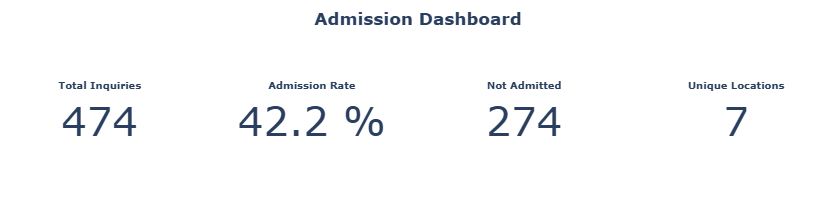

In [20]:

# --- Data ---
total_admissions = len(admissions)
admitted         = int(admissions['is_admitted'].sum())
not_admitted     = int((~admissions['is_admitted']).sum())
admission_rate   = round(admitted / total_admissions * 100, 1) if total_admissions else 0
unique_locations = int(admissions['location'].nunique())

# --- Figure ---
fig = go.Figure()

# Helper function (same style as yours)
def add_kpi(value, title, x_pos, suffix=""):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": f"<b>{title}</b>"},
        number={
            "font": {"size": 40},
            "suffix": suffix
        },
        domain={'x': x_pos, 'y': [0, 1]}
    ))

# --- Add KPIs (aligned like your format) ---
add_kpi(total_admissions, "Total Inquiries", [0.00, 0.22])
add_kpi(admission_rate, "Admission Rate", [0.26, 0.48], " %")
add_kpi(not_admitted, "Not Admitted", [0.52, 0.74])
add_kpi(unique_locations, "Unique Locations", [0.78, 1.00])

# --- Layout ---
fig.update_layout(
    title_text="<b>Admission Dashboard</b>",
    title_x=0.5,
    height=200,
    margin=dict(t=50, b=10, l=10, r=10),
    template="plotly_white"
)

fig.show()

## 📋 4. Admission Insights

In [5]:
# Admission Inquiries Over Time
adm_trend = (admissions.groupby('admission_month').size()
             .reset_index(name='Inquiries').sort_values('admission_month'))
fig = px.line(adm_trend, x='admission_month', y='Inquiries',
              color_discrete_sequence=[PALETTE['secondary']], markers=True)
fig.update_traces(line_width=2.5, marker_size=6)
clean_layout(fig, 'Admission Inquiries Over Time')
fig.update_xaxes(tickangle=-30)
fig.show()

In [6]:
# Admission Status Split
status_counts = admissions['status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']
fig = px.pie(status_counts, names='Status', values='Count', hole=0.55,
             color_discrete_map={'Admitted': PALETTE['secondary'], 'Not Admitted': PALETTE['danger']})
fig.update_traces(textposition='outside', textinfo='percent+label',
                  marker=dict(line=dict(color='white', width=2)))
clean_layout(fig, 'Admission Status Split')
fig.show()

In [7]:
# Inquiries by Location
loc_counts = admissions['location'].value_counts().reset_index()
loc_counts.columns = ['Location', 'Count']
fig = px.bar(loc_counts, x='Location', y='Count', color='Location',
             color_discrete_sequence=PALETTE['courses'], text='Count')
fig.update_traces(marker_line_width=0, textposition='outside')
fig.update_layout(showlegend=False)
clean_layout(fig, 'Inquiries by Location')
fig.show()

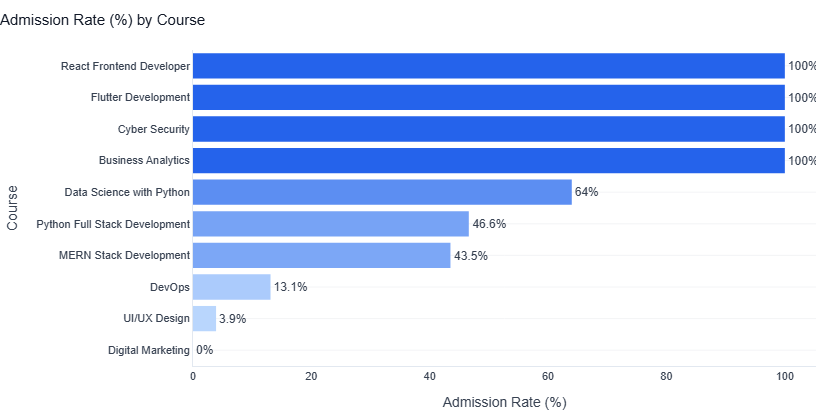

In [8]:
# Admission Rate by Course
course_adm = admissions.groupby('course')['is_admitted'].agg(['sum', 'count']).reset_index()
course_adm.columns = ['Course', 'Admitted', 'Total']
course_adm['Admission Rate (%)'] = (course_adm['Admitted'] / course_adm['Total'] * 100).round(1)
course_adm = course_adm.sort_values('Admission Rate (%)', ascending=True)
fig = px.bar(course_adm, x='Admission Rate (%)', y='Course', orientation='h',
             color='Admission Rate (%)',
             color_continuous_scale=['#BFDBFE', PALETTE['primary']],
             text='Admission Rate (%)')
fig.update_traces(texttemplate='%{text}%', textposition='outside', marker_line_width=0)
fig.update_coloraxes(showscale=False)
clean_layout(fig, 'Admission Rate (%) by Course', height=420)
fig.show()

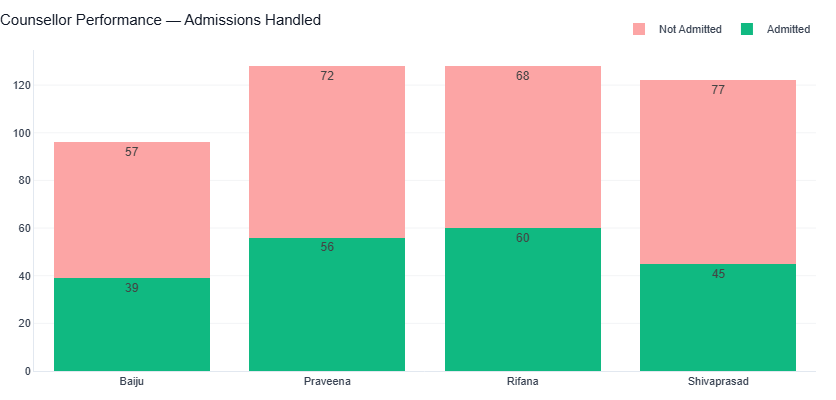

In [9]:
# Counsellor Performance
counsellor = admissions.groupby('attended_by')['is_admitted'].agg(['sum', 'count']).reset_index()
counsellor.columns = ['Counsellor', 'Admitted', 'Total Handled']
counsellor['Not Admitted'] = counsellor['Total Handled'] - counsellor['Admitted']
fig = go.Figure()
fig.add_trace(go.Bar(name='Admitted', x=counsellor['Counsellor'], y=counsellor['Admitted'],
                     marker_color=PALETTE['secondary'], text=counsellor['Admitted'],
                     textposition='inside', marker_line_width=0))
fig.add_trace(go.Bar(name='Not Admitted', x=counsellor['Counsellor'], y=counsellor['Not Admitted'],
                     marker_color='#FCA5A5', text=counsellor['Not Admitted'],
                     textposition='inside', marker_line_width=0))
fig.update_layout(barmode='stack')
clean_layout(fig, 'Counsellor Performance — Admissions Handled')
fig.show()

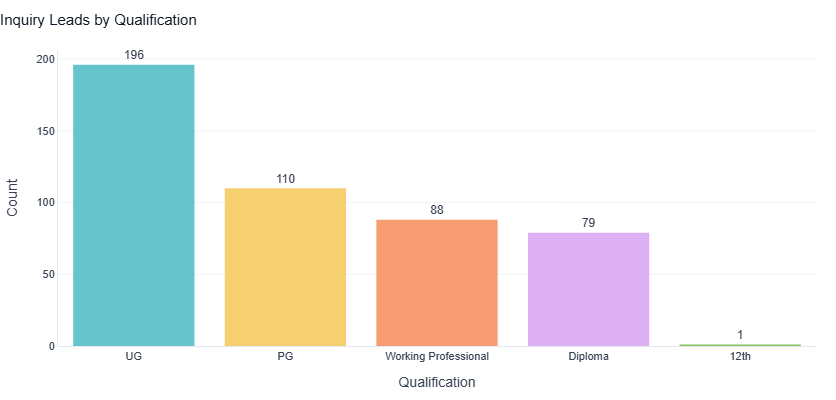

In [10]:
# Inquiry Leads by Qualification
qual_counts = admissions['qualification'].value_counts().reset_index()
qual_counts.columns = ['Qualification', 'Count']
fig = px.bar(qual_counts, x='Qualification', y='Count', color='Qualification',
             color_discrete_sequence=PALETTE['courses'], text='Count')
fig.update_traces(marker_line_width=0, textposition='outside')
fig.update_layout(showlegend=False)
clean_layout(fig, 'Inquiry Leads by Qualification')
fig.show()

## 🗂️ 5. Raw Admissions Data

In [11]:
print('=== Admissions Dataset ===')
display(admissions.reset_index(drop=True))

=== Admissions Dataset ===


,admission_id,student_id,student_name,mobile_no,email,location,qualification,course,mode,admission_date,attended_by,status,admission_month,is_admitted
0,ADM0001,STU0001,Kiran,9765861654,kiran1@gmail.com,Palakkad,Working Professional,MERN Stack Development,Offline,2025-01-02,Shivaprasad,Admitted,2025-01,True
1,ADM0002,STU0002,Tanya,9699233469,tanya2@gmail.com,Palakkad,UG,Data Science with Python,Offline,2025-01-02,Baiju,Admitted,2025-01,True
2,ADM0003,STU0003,Faisal,9190014738,faisal3@gmail.com,Palakkad,Working Professional,Data Science with Python,Online,2025-01-02,Rifana,Admitted,2025-01,True
3,ADM0004,STU0004,Ajay,9819774813,ajay4@gmail.com,Kottayam,UG,Python Full Stack Development,Online,2025-01-02,Praveena,Admitted,2025-01,True
4,ADM0005,STU0005,Rahul,9385106179,rahul5@gmail.com,Kottayam,PG,MERN Stack Development,Offline,2025-01-03,Baiju,Admitted,2025-01,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
469,ADM0470,STU0470,Nihal Raj,9552791148,nihal.raj470@gmail.com,Kochi,UG,Digital Marketing,Offline,2024-09-14,Praveena,Not Admitted,2024-09,False
470,ADM0471,STU0471,Ameen Nair,9586101490,ameen.nair471@gmail.com,Trivandrum,Working Professional,Python Full Stack Development,Offline,2024-09-15,Shivaprasad,Not Admitted,2024-09,False
471,ADM0472,STU0472,Jasim K,9715201830,jasim.k472@gmail.com,Kochi,Working Professional,Python Full Stack Development,Offline,2024-09-16,Rifana,Not Admitted,2024-09,False
472,ADM0473,STU0473,Sreya P,9965712098,sreya.p473@gmail.com,Trivandrum,Working Professional,DevOps,Offline,2024-09-17,Baiju,Not Admitted,2024-09,False
